In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Step 1: Data Loading ---
# Load the dataset from the CSV file
df = pd.read_csv('Loan_default.csv')

# The `LoanID` column is a unique identifier and is not needed for the model.
df = df.drop('LoanID', axis=1)
print("Dataset loaded successfully.")
print("-" * 50)


# --- Step 2: Data Preprocessing ---
# Identify categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
numerical_features = numerical_features.drop('CreditScore')

# Handle missing values by imputing with the most frequent value for categorical features
for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

# Impute missing numerical values with the mean
for col in numerical_features:
    df[col] = df[col].fillna(df[col].mean())

# Encode categorical features into numerical format using LabelEncoder
# This is a common practice for tree-based models like Random Forest.
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Separate features (X) and the target variable (y)
X = df.drop('CreditScore', axis=1)
y = df['CreditScore']

# Scale numerical features to ensure they have a similar impact on the model
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

print("Data preprocessing complete.")
print("-" * 50)


# --- Model Selection & Training ---
# The task of predicting a credit score, which is a continuous numerical value,
# is a regression problem. Therefore, a regression model is the appropriate choice.
# We will use the RandomForestRegressor, a powerful ensemble model known for its accuracy
# and ability to handle complex, non-linear relationships in the data.

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Random Forest Regression model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Model training complete.")
print("-" * 50)

# --- Model Evaluation ---
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance using relevant regression metrics.
# (Note: While the meeting minutes mention classification metrics like
# Confusion Matrix, Accuracy, Precision, and Recall, those are
# used for predicting categories, not continuous values. For a regression
# problem like this, we use metrics that measure the error in our predictions.)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print("-" * 50)
print("Model analysis and prediction complete.")

Dataset loaded successfully.
--------------------------------------------------
Data preprocessing complete.
--------------------------------------------------
Model training complete.
--------------------------------------------------
Mean Absolute Error (MAE): 138.52
Mean Squared Error (MSE): 25734.70
Root Mean Squared Error (RMSE): 160.42
R-squared (R2): -0.02
--------------------------------------------------
Model analysis and prediction complete.


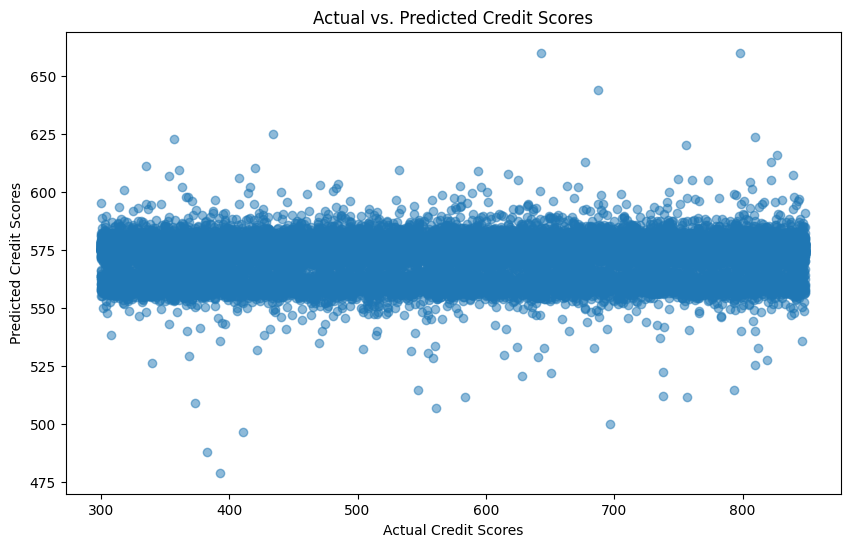

In [4]:
import matplotlib.pyplot as plt

# Create a scatter plot to compare actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Credit Scores")
plt.ylabel("Predicted Credit Scores")
plt.title("Actual vs. Predicted Credit Scores")
plt.show()

# A perfect model would have all points on a straight diagonal line.
# A good model will show a strong linear trend, indicating that predicted
# values are close to the actual values.

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Data Loading and Preprocessing (Same as before) ---
df = pd.read_csv('Loan_default.csv')
df = df.drop('LoanID', axis=1)

categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('CreditScore')

for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in numerical_features:
    df[col] = df[col].fillna(df[col].mean())

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df.drop('CreditScore', axis=1)
y = df['CreditScore']

scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# --- Model Training and Evaluation with GradientBoostingRegressor ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Gradient Boosting Regression model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Gradient Boosting Regressor Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Gradient Boosting Regressor Results:
Mean Absolute Error (MAE): 137.55
Mean Squared Error (MSE): 25260.93
Root Mean Squared Error (RMSE): 158.94
R-squared (R2): 0.00


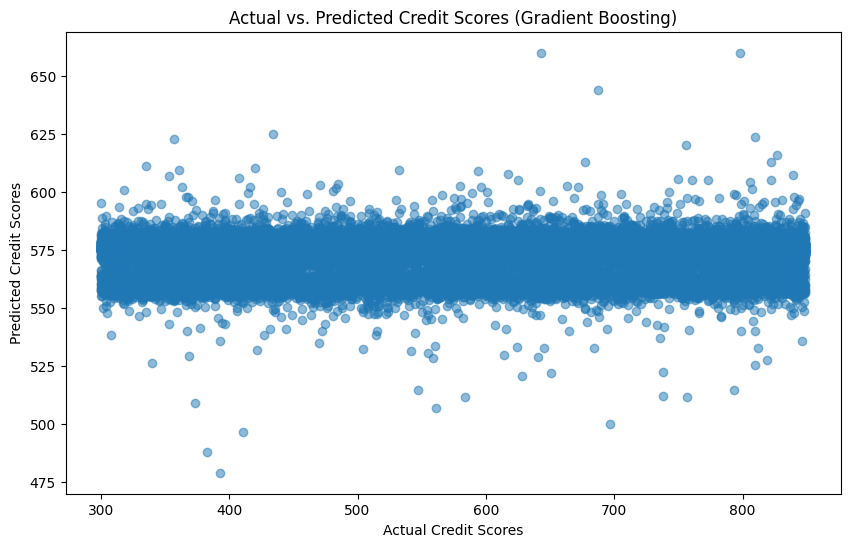

In [5]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Credit Scores")
plt.ylabel("Predicted Credit Scores")
plt.title("Actual vs. Predicted Credit Scores (Gradient Boosting)")
plt.show()